In [1]:
import sys
original_sys_path = sys.path.copy()
sys.path.append('../')
from utils_models import *
# dq.set_precision( 'simple')
dq.set_device('gpu')


# Define the operators

In [2]:
solver = dq.solver.Tsit5(
                    max_steps = int(1e4*1000),
                )


EJ = 2
EC = EJ/4
EL = EJ/20
n_lvls_fluxonium = 40
n_lvls_resonator = 20
Er = 11.46660156/2
qsf = qs.Fluxonium.create(
    n_lvls_fluxonium,
    {"Ej": EJ, "Ec": EC, "El": EL, "phi_ext": 0.0},
    N_pre_diag=120,
    use_linear = False
    )

res = MyResonator.create(
    n_lvls_resonator,
    params = {"ω":Er,"α":0},
    use_linear = False,
)

devices = [qsf, res]
Ns = [device.N for device in devices]
fn = qs.promote(qsf.ops["n"], 0, Ns)
rn = qs.promote(res.ops['n'], 1, Ns)
a = qs.promote(res.ops['a'], 1, Ns)
a_dag = qs.promote(res.ops['a_dag'], 1, Ns)

g_tf = 0.2
system = qs.System.create(devices, couplings=[
    g_tf *  fn @ rn
    ])

system_evals_sorted, system_evecs_sorted, product_indices_sorted_by_eval = calculate_eig(Ns, system.get_H())
driven_op = transform_op_into_dressed_basis_jax(rn, system_evecs_sorted.T)
dressed_a = transform_op_into_dressed_basis_jax(a, system_evecs_sorted.T)
dressed_a_dag = transform_op_into_dressed_basis_jax(a_dag, system_evecs_sorted.T)

dressed_indices_to_keep = []
for ql in range(3):
    for rl in range(70):
        dressed_indices_to_keep.append( find_closest_dressed_index(ql*70+rl, product_indices_sorted_by_eval) )
dressed_indices_to_keep = jnp.array(dressed_indices_to_keep)
def truncate(data: jnp.array):
    if data.shape[1] == 1:
        return jnp.take(data, dressed_indices_to_keep, axis=0)
    elif data.shape[0] == data.shape[1]:
        return jnp.take(jnp.take(data, dressed_indices_to_keep, axis=0), dressed_indices_to_keep, axis=1)
    else:
        raise Exception('shape error')


# run the simulation

In [4]:
system_evals_in_product_indices, system_evecs_in_product_indices = system.calculate_eig_linear()
w_d = system_evals_in_product_indices[0,1] - system_evals_in_product_indices[0,0]
pulse_length = 280
amp_with_2pi = 1e-2 * 2*jnp.pi
t_rise = 20
t_tot = t_rise + pulse_length
tlist = jnp.linspace(0,t_tot,int(t_tot))


pulse_shape_args={
    'w_d': w_d,
    'amp': amp_with_2pi/(2*jnp.pi),
    't_rise': t_rise,
    't_square': 999
}      


def _H(t):
    _H =  2 * jnp.pi *truncate(jnp.diag(system_evals_sorted))
    _H += truncate(driven_op) * square_pulse_with_rise_fall(t, pulse_shape_args)
    return _H 
H =  dq.timecallable(_H)

psi0_list = [truncate(dq.basis(n_lvls_fluxonium * n_lvls_resonator,
                               find_closest_dressed_index(ql*n_lvls_fluxonium + 0, product_indices_sorted_by_eval))
                               ) for ql in range(3)]  
e_ops = [truncate(dressed_a_dag @ dressed_a) ]


In [5]:

result = dq.sesolve(
            H = H,
            psi0 = psi0_list,
            tsave = tlist,
            solver = solver,
            exp_ops = e_ops
            )

# 210 level, 3 process, 

20 ns => 18s

40 ns => 36s

400ns => 6 min?

600ns => 12 min


 /home/kai/miniconda3/envs/test/lib/python3.10/site-packages/jax/_src/array.py: 403

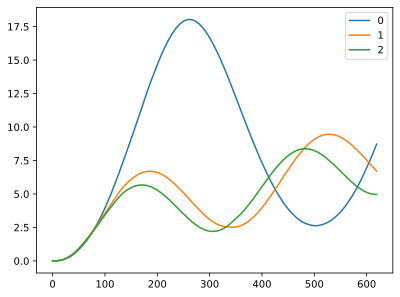

In [27]:
for ql in range(3):
    plt.plot(result.expects[ql][0],label=f'{ql}')
plt.legend()

In [ ]:

##############################################################################
#
#
# These functions are about re-construting the product state involving first three qubit levels
#
#
##############################################################################
sorted_dressed_indices_to_keep = sorted(dressed_indices_to_keep)
product_to_truncated_dressed = {}
for ql in range(3):
    for rl in range(70):
        dressed_idx = find_closest_dressed_index(ql*70+rl, product_indices_sorted_by_eval)
        product_to_truncated_dressed[(ql,rl)] = sorted_dressed_indices_to_keep.index(dressed_idx)

sign_multiplier = {}
for i in range(len(dressed_indices_to_keep)):
    evec = system_evecs_sorted[i]
    max_abs_index = np.argmax(np.abs(evec))
    max_abs_value = evec[max_abs_index]
    if max_abs_value > 0:
        sign_multiplier[i] = 1
    elif max_abs_value < 0:
        sign_multiplier[i] = -1
    else:
        raise Exception('max being 0')

def truncated_dressed_to_product(dressed_dm: qutip.Qobj, 
                        product_to_truncated_dressed: dict, 
                        sign_multiplier:dict,
                        ) -> qutip.Qobj:
    dressed_dm_data = dressed_dm
    if dressed_dm_data.shape[1] == 1:
        dressed_dm_data = qutip.ket2dm(dressed_dm_data)
    dressed_dm_data = dressed_dm_data.full()

    subsystem_dims = [max(indexes) + 1 for indexes in zip(*product_to_truncated_dressed.keys())]
    rho_product = np.zeros((subsystem_dims*2), dtype=complex) # Here rho_product is shaped like (dim1,dim2,dim1,dim2)
    for product_state, dressed_index1 in product_to_truncated_dressed.items():
        for product_state2, dressed_index2 in product_to_truncated_dressed.items():
            element = dressed_dm_data[dressed_index1, dressed_index2] * sign_multiplier[dressed_index1] * sign_multiplier[dressed_index2]
            rho_product[product_state+product_state2] += element # Using index like (lvl1, lvl2, lvl1, lvl2) to access of of the entries

    two_lvl_qbt_dm_size = np.prod(subsystem_dims)
    rho_product = rho_product.reshape((two_lvl_qbt_dm_size,two_lvl_qbt_dm_size))
    rho_product = qutip.Qobj(rho_product, dims=[subsystem_dims, subsystem_dims])

    return rho_product


In [ ]:
result.states